# COVID-19 Predictive Model
## Jess Denton
### Module: DC3DMN

## Table of Contents
1. Academic Integrity Statement
2. Introduction
3. Ingesting and Preparing the Data
4. Exploratory Data Analysis
4. Building the Model
5. Testing and Iterations
6. Conclusion
7. References
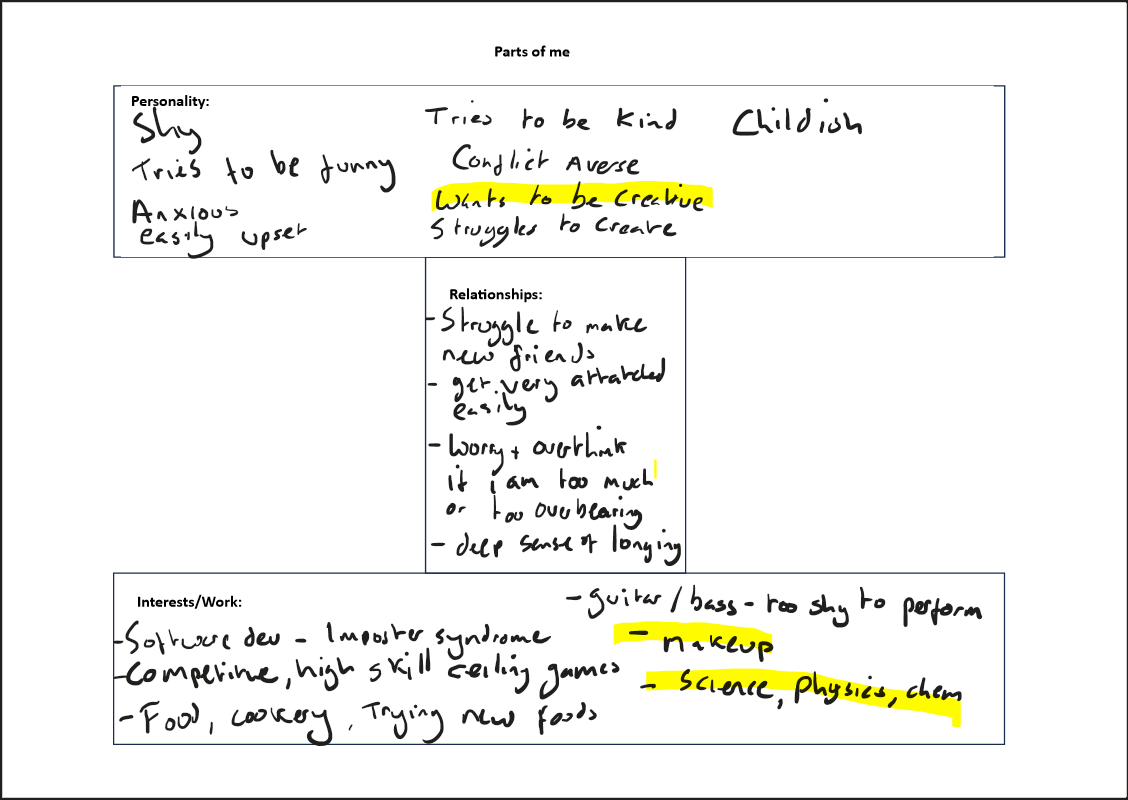

### Academic Integrity Statement
 I declare that I have personally prepared this assignment. The work is my own, carried out personally by me unless otherwise stated and has not been generated using Artificial Intelligence tools unless specified as a clearly stated approved component of the assessment brief. All sources of information, including quotations, are acknowledged by means of the appropriate citations and references. I declare that this work has not gained credit previously for another module at this or another University.

I understand that plagiarism, collusion, copying another student and commissioning (which for the avoidance of doubt includes the use of essay mills and other paid for assessment writing services, as well as unattributed use of work generated by Artificial Intelligence tools) are regarded as offences against the University’s Assessment Regulations and may result in formal disciplinary proceedings.

### Introduction
This notebook will analyse a provided data extract of COVID-19 test results to train a machine learning model and provide predictions over a similar unseen dataset. The code sections will be applying data mining techniques in order to extract valuable features from the data set and train a machine learning algorithm on them. The report blocks will explain the rationale, underlying theory and reflect on the processes applied to break down and analyse the dataset.
Data mining is defined as *'the use of machine learning and statistical analysis to uncover patterns and other valuable information from large data sets' (Holdsworth, J. 2024)*.

## Ingesting and Preparing the Data

### Raw Data & Imports
The first part of data mining is to understand the dataset that will be used. The sample data extract has 3999 rows across 108 columns. 105 of the columns contain features, these are columns that contain clinical measurements that case represent a test, symptom or observation for a specific record. 2 of the columns contain obfuscated patient information and the final column contains the result of a COVID-19 test. The dataset has a mix of types of data (not to be confused with their computational dtype). There is interval data such as column feat_Urine - pH, where there is a numeric quality to the data, but where certain mathematical operations do not make sense (sum or product operations) but the difference between values does make sense. pH is a great example of this as adding or multiplying different values in the pH column is meaningless, but the difference between them could help identify who is more likely to have a positive COVID-19 assay. There are also many continuous attributes present, where the attributes have Real number values. This data type makes up the bulk of the dataset. Finally, there are nominal attributes, the most important of which is the COVID-19 Test result column, which has a binary state of positive or negative. This will be the value that the model is tasked to predict for unseen sets of data. Currently, the dataset provides rich data, but poor information. Which means it is difficult to draw conclusions or predict results with it in its raw form. It is difficult for a human to parse large data sets and extract meaningful conclusions and the data mining process aims to reduce that gap, in this case providing an algorithm that will be used to predict cases of COVID-19 among a population.

 In this case the aim is to make a model that carries out a form of binary classification and predict either a positive or negative COVID-19 assay. Classification is a type of data mining that aims to isolate features that have high influence over the value of a nominal class, and use them to predict values from that nominal class from an unseen set of feature values. *Geeks for Geeks* define classification as; *'Classification in data mining is a supervised learning approach used to assign data points into predefined classes based on their features. By analysing labelled historical data, classification algorithms learn patterns and relationships that enable them to categorize new, unseen data accurately.'(GeeksForGeeks, 2018)*. The first step is to ingest this data into the notebook using the python pandas library.

Pandas *is a fast, powerful, flexible and easy to use open source data analysis and manipulation tool (Pandas, 2019).* It allows construction of data frame objects, which contain multiple series of data with labels (columns) and indexes (rows). This becomes a manipulatable representation of all the data contained within the CSV file. It also interacts with many of the other libraries that will be used for visualisation and machine learning, which makes it highly versatile and a key tool for any data mining effort that uses python. Firstly pandas needs to be imported, as well as all other libraries that will be used throughout the notebook.


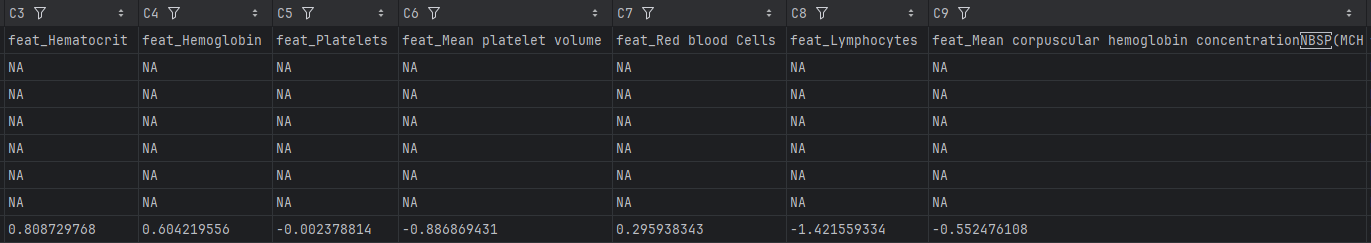

In [ ]:
#Run imports for libraries to be used
import pandas as pd
import json
from sklearn.experimental import enable_iterative_imputer
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import PowerTransformer
from imblearn.over_sampling import RandomOverSampler
import re
import missingno as msno
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
import sklearn
from scipy.cluster.hierarchy import fcluster
from sklearn.tree import DecisionTreeRegressor
from sklearn.experimental import enable_iterative_imputer

#Set up options for pandas return functions
pd.options.display.max_rows = 100
pd.options.display.max_columns = 110
sklearn.set_config(transform_output="pandas")

### Ingesting the raw CSV
The data extract provided is a CSV file with ANSI encoding. Pandas creates data frame objects which hold the ingested data in a 2-dimensional mutable array. The 'read_csv' method from Pandas is invoked to load the data into a dataframe, using a separate JSON schema to specify data types for each column in the CSV to make the data simpler to work with. Usually this method will attempt to infer the data type (also referred to as dtypes) for each column, but this can lead to unexpected dtypes in columns which may result in errors with data processing further in the process. Using a schema removes ambiguity and reduces the number of casts done in the processing chain, which subsequently reduces the opportunities to induce errors. There is also an additional parameter to cast values to True or False for boolean columns, accounting for the most common ones in the dataset.

In [ ]:
#load the schema
with open('ingest_schema.json') as f:
    schema = json.load(f)

#Use the schema and other params to ingest the csv
df_all = pd.read_csv(
    filepath_or_buffer ="CW_data.csv",
    encoding='ANSI',
    dtype = schema,
    true_values = ["positive", "detected", "TRUE", 'present'],
    false_values = ["negative", "not_detected", "FALSE", 'absent'],
    na_values = ["not_done"],
    on_bad_lines = "warn"
    )
#Check the head, shape and class distribution of the dataframe
class_counts = df_all['SARS-Cov-2 exam result'].value_counts()
class_ratio = class_counts / len(df_all)
print(f'Shape of df_all is: \n{df_all.shape} \nand the class distribution is: \n{class_counts} \nwith a bias of \n{class_ratio}')
df_all.head(10)

The data is successfully loaded into a dataframe and immediately the class imbalance is apparent. The imbalance is roughly 90:1 for Negative vs Positive COVID-19 test results. This will need to be addressed later when fitting models. Aside from that, printing the head of the dataframe shows the top 10 rows and all columns of the data as pandas has stored it. This is a quick and simple way for a human to verify that the data is generally as expected. For example, it would be easy to see if something had errored if a column with mostly numerical values suddenly gained a string as an entry. This is not foolproof as it only looks at a tiny fraction of the data, and even still the size and complexity of the data still means that it is not suitable for human interpretation.

The next step normalises the column headers to make sure they are callable by label, as they are case sensitive and must be implicitly named in order to address individual columns. The code strips any additional spaces and removes any invisible ones also. This will also be used to normalise any incoming data for the model to predict over once they are trained.

In [ ]:
#clean column labels for invisible space characters, create function for use on unseen data.
def clean_cols(df):
    # Remove occurrences of \xa0
    df.columns = [re.sub(r'\s+', ' ', col).strip() for col in df.columns]
    return df
df_all = clean_cols(df_all)
# double check columns are still there as expected
print(f'df_all shape post column header clean is: {df_all.shape}')
df_all.head(1)

### Preprocessing
Although the data is now ingested, it will need a number of preprocessing steps before it is fit for training models on. There are some obvious steps to take with the data initially, but other steps will need visualisations or other aggregations in order to become visible. The preprocessing section will address outliers, missing values and insuring the dtypes are all able to be interpreted numerically, which may require casting of ordinal values to a numerical equivalent. Firstly, while an ID column is very useful when data is stored in a database or when the ability to look up a single record is a requirement, it is practically useless in a machine learning context. This is because it has no bearing on the class of a record. As well as this the next cell will also create a copy of the dataframe for use as a baseline model later.

In [ ]:
#Remove the patient ID column and check the rest of the data is as expected
df_all.drop('Patient ID', axis = 1, inplace = True)
#Create a copy of df_all before preprocessing for a baseline model later.
df_original_predictors = df_all.copy()
df_all.head(1)

It is now evident from looking at the head of the data frame that there is a large proportion of missing values (values of NaN or <NA>) in the dataset. This poses an issue for data mining, as noted in the Korean Journal of Anesthesiology,*"...the absence of data reduces statistical power, which refers to the probability that the test will reject the null hypothesis when it is false. Second, the lost data can cause bias in the estimation of parameters. Third, it can reduce the representativeness of the samples. Fourth, it may complicate the analysis of the study. Each of these distortions may threaten the validity of the trials and can lead to invalid conclusions" (Kang, H. 2013).* The issue of missing data is common across all fields of data engineering and when unhandled can lead to 1 or all of the problems laid out above. The preprocessing step will look to remove columns and rows with large amounts of missing values in order to increase the statistical power overall without overly reducing the resolution of the dataset. While many missing values will remain they will be handled later via other methods, as removing all missing values from the dataset is impossible if it is to retain any statistical relevance. To start, some columns have either got only NaN values or values that are all identical. Columns that are all NaN are useless for data mining as they cannot be used as a predictor for the model. The same goes for columns where the value is all equal but not NaN, as these columns have no variance they can be discounted as being influential over the COVID-19 test result.

In [ ]:
#Find all columns with only a single unique value in the column
df_single_values =  df_all.loc[:, df_all.nunique(dropna = False) == 1]
# sense check and verify 1 unique value only
df_single_values.head(5)

In this dataset there are 5 columns that have only got 1 unique value contained in them, and they all happen to be missing value columns. These can be safely dropped from the dataframe.

In [ ]:
#Drop all columns with 1 or less unique values from df_all
df_all = df_all.drop(labels = df_single_values.columns, axis = 1)

The same logic should be applied for rows with all values missing also, as their classification has no feature information that can be used for modelling, meaning its class value would only serve to increase the already heavily biased class totals. Considerations need to be made to exclude the age quantile column and the class column, as they are the only columns populated for every record.

In [ ]:
#Ignore the patient quantile and exam result
ignored_cols = ["Patient age quantile", "SARS-Cov-2 exam result"]
all_feats_cols = df_all.columns.difference(ignored_cols)

#Drop all rows that are fully missing all feature values
df_all = df_all.dropna(how = "all", subset = all_feats_cols)
#check the new shape of the dataframe to see how many rows were dropped
print(f'The current shape of df_all is: {df_all.shape}')

The next thing to handle is the columns labeled with dytpe string from the ingestion schema. Machine learning algorithms work best (and often only work at all) on numeric values. Using a table to visually inspect the contents of each column with applicable dtype will determine the strategy required to address each one.

In [ ]:
# Identify string/object/category columns and look at what they actually contain
df_string_cols = df_all.select_dtypes(include=['object', 'category', 'str'])

print(f"{'COLUMN NAME':<35}  {'UNIQUE VALUES'}")
for col in df_string_cols.columns:
    unique_list = df_all[col].unique().tolist()
    #Format the column name and the list for better readability
    col_label = f"**{col}**"
    values_str = ", ".join([str(val) for val in unique_list])
    # Print the column and its values (trunc down to stop going on forever)
    if len(values_str) > 100:
        values_str = values_str[:97] + "..."
    print(f"{col:<35} | {values_str}")
df_all.head(1)

The above table shows there are 3 columns that have categoric data in them; urine aspect, urine crystals and urine colour. There is also a column of integer values, but there are entries for '<1000' which mean that the entire urine leukocytes column had to be imported as a string. Additionally, there are 2 columns that have 'normal' and 'Ausentes' as values. These couldn't be accounted for in the ingestion schema and need to be manually mapped now. It is important to preserve NaN values, so that will also be accounted for during the processing. For the leukocytes column, the values of '<1000' can be replaced with 999 and then the whole column can be recast as a float, allowing for numerical processing. The values of 'normal' and 'Ausentes' can be mapped and replaced accordingly with 0 values. Their columns cannot be recast as a specific type currently but will be handled in the full dataframe numeric cast later. The categoric columns need to be handled via One-hot encoding, which *'...is a technique for representing categorical data as numerical vectors, where each unique category is represented by a binary column with a value of 1 indicating its presence and 0 indicating its absence (Rojo-Echeburúa, 2024).* This is a step that prevents data being lost from the categoric columns, but still allows numerical operations to be applied.

In [ ]:
#keep an eye on the shape to make sure nothing is going wrong
print(f'shape pre casting & mapping is: {df_all.shape}')
#Handle these columns by converting them to numerical values where possible.
df_all['feat_Urine - Leukocytes'] = df_all['feat_Urine - Leukocytes'].replace('<1000', 999).astype('Float64')
#normal mapping
mapping = { 'normal': 0, 'Ausentes' : 0}
df_all = df_all.replace(mapping)
#columns that have categorical data with unknown relationships i.e. if ordinal or not.
categorical_cols = ['feat_Urine - Aspect','feat_Urine - Crystals','feat_Urine - Color']
# utilise one-hot encoding to make these columns split out into numeric values columns instead.
df_all = pd.get_dummies(
    df_all,
    columns = categorical_cols,
    dummy_na = True,
    prefix = categorical_cols,
    dtype = 'boolean'
    )
# apply a numeric cast to the whole dataframe.
print(f'shape pre numeric cast is: {df_all.shape}')
df_all = df_all.apply(pd.to_numeric)
print(f'shape post numeric cast is: {df_all.shape}')
df_all.head(1)

In data mining and machine learning, data leakage is one of the top priorities to eliminate. Data leakage is defined as *"...when a model uses information during training that wouldn't be available at the time of prediction" (Mucci, 2024).* If leakage occurs then a model looks accurate until it is deployed onto unseen data, at which point it yields inaccurate results and false insights. In order to mitigate data leakage, data miners have to carry out data processing steps in particular orders, always trying to minimise the inclusion of future information to keep the model trained as representatively as possible. One of the key methods for this is using a test-train split. With the full dataset ingested, splitting it into 2 parts allows the model to be trained on one set of data, while remaining completely in the dark about the other set. This helps to properly evaluate a models performance on unseen data sets. Any part of the model that is being fitted, will only be fitted to the training set. Any transformations that subsequently need to be applied will be applied to both the training and test sets, to make sure that the dimensionality and shape remains the same. In this case, with a huge class imbalance the test-train split needs to be stratified on the classifiers, making sure that the ratio of classifiers in each split is maintained.

In [ ]:
# Split out the classifiers and predictors
df_classifiers = df_all['SARS-Cov-2 exam result']
df_predictors = df_all.drop(['SARS-Cov-2 exam result'], axis = 1).copy()
#Carry out test train split
df_predictor_train, df_predictor_test, df_classifier_train, df_classifier_test = train_test_split(df_predictors, df_classifiers, test_size = 0.2, stratify = df_classifiers, random_state = 1)
print(f'The shape of the test-train splits are:\nTraining Predictors: {df_predictor_train.shape}\nTraining Classifiers: {df_classifier_train.shape}\nTest Predictors: {df_predictor_test.shape}\nTest Classifiers: {df_classifier_test.shape}')

## Exploratory Data Analysis (EDA)
When first looking at a dataset it is imperative to carry out some forms of EDA. This ensures that the right kinds of processing are carried out to uncover the most impactful relationships and correlations. When loading in the dataset it was previously established that there is a significant class imbalance present, as well as a high percentage of NaN values, both of these will have to be handled going forward, but there are other insights to look at. The steps already looked at in the ingestion stage are:

* Class imbalance. Some common methods for testing model performance are not suitable. As part of the brief it is mentioned that the F1 score will be used to assess model performance from a marking perspective, as it already takes into account this issue of class imbalance. For this reason the F1 score will also be the primary performance criteria for this model.

* High percentage of NaN values. This is harder to deal with as there could be certain features that are only have results for patients who are more likely to have a positive COVID-19 assay and dropping columns that have high percentages of NaNs outright could lead to these features being absent and the model losing out on critical information. This is difficult to discern with no expertise in the area, and feature selection would be more robust if an expert could weight certain columns based on their value to the model.

### Correlation and Clustering
The next step is looking at a correlation heatmap to see if there are likely to be redundant columns, which can be used to inform feature reduction steps. To do so a correlation matrix can be formed, based on the spearman's rank. The correlation of the dataset will show if there are certain columns that have redundant features. This is useful as it simplifies the models and prevents potential double weighting of results, leading to a biased model. The data analysis steps will help inform the feature reduction steps further down the line.

In [ ]:
#Correlation matrix
corr_matrix = df_predictor_train.corr(method = 'spearman').abs()
heat_mask = np.triu(np.ones_like(corr_matrix, dtype = bool))
plt.figure(figsize = (12,10))
sns.heatmap(corr_matrix, mask = heat_mask, cmap = 'magma', vmin = 0, vmax = 1, center = 0, square = True)
plt.title('Correlation Matrix Heatmap')
plt.show()

The matrix above shows areas of high correlation around the blood gas analysis sections and parts of the urine analysis section. There are also many features with low correlations. Given the current number of features in the dataset, these results justify use of principal component analysis to carry out feature reduction. In addition to the heat map, a dendrogram can be plotted to show the hierarchical clusters within the data. This is used over k-means centroid based clustering as the data has highly variable densities and high dimensionality.
To refine this further and view the clusters that may be suggested in the dataset, a dendrogram can be drawn using the correlation matrix that was defined earlier. This is then converted to a distance matrix and the linkage between them is found using agglomerative clustering *(Nobel 2024)*. The ward clustering method was chosen for this application as it minimises the internal cluster variance making the clusters easier to see and tends to perform better in this use case vs other linkage methods *(Ferriea et al. 2009)*. This clustering will then show a representation that helps verify how many clusters is roughly expected from the upcoming PCA.

In [ ]:
#methods will not work with NaN values.
no_nan_corr = corr_matrix.dropna(how = 'all', axis = 0).dropna(how = 'all', axis=1)
no_nan_corr.fillna(0, inplace = True)
dist_matrix = 1 - no_nan_corr.abs()
#squareform to cut off the duplicated triangle of data in the matrix like with the heatmap
condensed_dist = squareform(dist_matrix, checks = False)
clusters = hierarchy.linkage(condensed_dist, method = 'ward')
plt.figure(figsize=(15, 25))
threshold = 1.45

colour_cluster_dendrogram = hierarchy.dendrogram(
    clusters,
    labels = no_nan_corr.columns,
    orientation = 'left',
    color_threshold = threshold,
    above_threshold_color = 'black'
)

plt.axvline(x = threshold, color = 'red', linestyle = '--', label = f'Threshold: {threshold}')
plt.title('Hierarchical Clustering ', fontsize = 12)
plt.xlabel('Distance')
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.legend(loc = 'upper left')
plt.show()

The threshold in the above dendrogram plot was derived using the elbow method for hierarchical clustering. This is a heuristic method where the distance moved at each merge is plotted and the point where the gradient of the resulting plot changes the most is the point at which the threshold should be drawn. In this case, the elbow plot shows a suggested threshold of about 1.45, which is then used to create the above dendrogram and the resultant 6 suggested clusters.

In [ ]:
#find the distances of the last 10 merge operations
distances = clusters[-10:, 2]
#flip the distances around to plot the biggest jumps first
distances_rev = distances[::-1]
# make into nice to read x label.
x_labels = np.arange(1, len(distances) + 1)

plt.figure(figsize = (10, 5))
plt.plot(x_labels, distances_rev, marker = 'x', linestyle = '--', color = 'black')
plt.title('Verify threshold with elbow plot')
plt.xlabel('Number of Clusters')
plt.ylabel('Distance')
plt.xticks(x_labels)
plt.grid(True)
plt.show()

### Outlier Visualisation
Visualising outliers and distributions within the data will help inform the methods used to reduce skew and remove outliers. If outliers are present in data used to train models it can lead to less accurate models as they get mislead during the training process *(Brownlee, 2013)*. Using box plots can easily help visualise these. For each of the clusters identified in the correlation section, box plots can be created that show the outliers and distribution of each feature. This does exclude some columns from the df_predictor_training due to the NaN filtering that was carried out, but will give a good overall view of the data.

In [ ]:
# create the clusters from the dendrogram and make a series matched with the column names.
cluster_features = fcluster(clusters, t = 1.45, criterion = 'distance')
cluster_cols = pd.Series(cluster_features, index = no_nan_corr.columns)
# go through each cluster, get the feature names and make a box plot of those features.
for i in range(1, 7):
    feats = cluster_cols[cluster_cols == i].index.tolist()
    plt.figure(figsize = (10, 5))
    plt.title(f'Cluster {i}', fontsize = 12)
    sns.boxplot(data = df_predictor_train[feats], orient = 'h')

When looking at the box plots, cluster 2 and cluster 6 stand out immediately, cluster 2 contains binary data with a heavy balance to one particular value. This makes the plots thin lines with a plot of outliers at the opposite side of the graph. This is not very helpful for drawing any conclusions aside from the imbalances in the feature set. Cluster 6 shows an extreme outlier for the urine_leukocytes feature. This makes the box plot hard to understand as all the other features get squashed down due to the extreme scaling as a result of the outlier. This is still useful information as it identifies this feature as being problematic. This is particularly interesting as the data is supposedly pre normalised to a mean of 0 and 1 standard distribution. This kind of result would indicate use of a power transformer such as Yeo-Johnson, which performs scaling and skew in the dataset as part of a single transformation, while allowing for transformations on both positive and negative skews, which the plots suggest would be present in the dataset.

### Missingness
As part of the ingestion of the data, columns and rows that were all NaN or had 0 variance were removed. However, it is easy to see from the head of df_all that there are still a high number of missing values left in the dataset. Columns with high numbers of missing values could lead to poor quality training data with a reduction in statistical power or the introduction of bias in the model predictions. for the model or potentially bias it. In most cases, removal of columns with high percentages of missing data is a good way to handle this issue but analysis of the 'missingness' of the dataset should be carried out to determine the best approach. The aim of missing data analysis is to help try and determine the mechanism of the missing data. These mechanisms describe the relationships between missing data points and are known as:
* Missing completely at random (MCAR) where missingness is unrelated to all other features and to the classification, this data usually doesn't influence bias in a model, but it can reduce statistical power, it should be handled with multiple imputation methods to limit the reduction in power.
* Missing at random (MAR) where missingness is related to other features but not related to the classification. This cannot be tested for but can also be handled by multiple imputation methods.
* Missing not at random (MNAR) where missingness is directly related to the classification. This cannot be tested for and introduces bias to the model.
*(Geiser, 2025)*.

In this dataset it is not likely to have the MNAR mechanism, as there is a classification result for every entry in the dataset. Utilising plots of missing data can help construct an apporach to handling the missing data.

In [ ]:
# Create a simple plot of missing values per feature
missing_per_column = df_predictor_train.isnull().sum(axis=0)
#Plot them on a simple graph
plt.figure(figsize = (20, 10))
plt.grid(True)
plt.plot(missing_per_column)
plt.xlabel('Feats')
plt.ylabel('Number of NaNs')
plt.xticks(rotation = 90)

In [ ]:
#alternate plots using msno
msno.bar(df_predictor_train, figsize=(15 ,15), fontsize=8)

The 2 plots above show that there is a high variance to the amount of values missing per feature. Some features have all data points present, but these are mostly the extra columns that were created by One-Hot encoding when the categorical data was dealt with. There are also features that are missing almost all the data points such as vitamin b12. Next a plot of the correlation of missingness for each column can show if features are more or less likely to be present based on the presence of a different feature.

In [ ]:
msno.heatmap(df_predictor_train, figsize= (30 ,30), fontsize = 10)

The heatmap shows that there is a high correlation between the presence of a lot of features in the dataset, meaning that they are more likely to be MAR rather than MCAR in those cases.
It is easy to see on the graph that there are a vast number of columns missing a high proportion of their data. Little's MCAR test could be used on the dataset to determine if there is a case for MCAR in the data, but given the high correlations seen in the heatmap it is highly likely that the data is mostly MAR and given that the handling of both MCAR and MAR data can be done via multiple imputation it is more time and computationally efficient to skip further testing at this point and continue forward with the data processing.

## Processing
This section contains processing steps that will further prepare the data for use in training the classifier models. It will cover the following steps:
* Dealing with NaN values
* Dealing with outliers and skew
* Performing feature reduction via PCA
* Dealing with class imbalance

Firstly as identified in the EDA there is an issue of missing data points that are of the MAR mechanism. Outright dropping high NaN columns will not be the best way to deal with this as the loss of statistical power will be too great. However, columns with over 95% missing data are likely to be introducing more noise than statistical power. So they should be included in listwise deletion over the dataset as using them in imputation could cause problems.

In [ ]:
# Check shapes pre drop:
print(f'Training shape is: {df_predictor_train.shape}\nTesting shape is: {df_predictor_test.shape}')
#Drop all columns missing over 95% data points.
df_predictor_train.dropna(axis = 1, inplace=True, thresh = int(0.05 * len(df_predictor_train)))
# mirror the drop in the testing set
df_predictor_test.drop(inplace=True, columns = df_predictor_test.columns.difference(df_predictor_train.columns))
#check how many columns are left post drop
print(f'The current shape of the data after dropping the columns is: \n Training: {df_predictor_train.shape}\nTesting: {df_predictor_test.shape}')

The next step is to handle the rest of the NaN values via imputation. This is an algorithm that 'guesses' the most likely entry for a missing data point based on the other data in the dataset. Simple imputation could be in the form of replacing the missing values with the mean or median value for the column, but given the amount of missing values that still exist this would definitely bias the training of any models. The best case for this dataset is to use a multiple imputation method such as Multiple Imputation by Chained Equations (MICE). This will carry out a simple imputation initially and then iterate further imputations via regression *(Raf. 2024)*. This can be further augmented with regression trees to improve the imputation process.

In [ ]:
#create an imputer and regressor object and fit it on the train set.
regressor = DecisionTreeRegressor(
    max_features = 'sqrt',
    random_state = 1
)
imputer = IterativeImputer(
    estimator = regressor,
    max_iter = 50,
    initial_strategy = 'median'
)
imputer.set_output(transform = "pandas")
predictor_train = imputer.fit_transform(df_predictor_train)
#use the fitted imputer on the testing set
predictor_test = imputer.transform(df_predictor_test)

### Outliers & Skew
Having high skew or many outliers in the dataset will impact the ability of a model trained on it to reliably predict classification. A data set with low skew would follow a Gaussian distribution (also known as a normal distribution), forming a neat bell curve of results when plotted. Statistically almost all the data (95% of all points) in a Gaussian distribution are within 2 standard deviations from the mean *(Kaneko et al., 2008)*. The curve for a Gaussian distribution exhibits symetry around its median value, whereas skewed distributions make it much harder to distinguish where symetry occurs. Skew can be positive or negative, depending on which side of the curve is shifted along the x-axis. A positive skew shows a long tail that extends to the right hand side of the distribution curve. It has a mean greater than the mode and the median. Negatively skewed data is the opposite, with the tail to the left and the mean less than the mode and median. *(Sharma, R. 2022).*

As part of the EDA, the cluster box plots showed a potential for high positive skew as well as some extreme outliers. There was also a much smaller amount of negative skew present for some plots. To confirm this a distribution histogram can be plotted. The histogram needs to exlcude boolean values as the binary nature of these columns doesn't work with skew calculations or transformations.

In [ ]:
print(df_predictor_train.dtypes)

In [ ]:
sns.histplot(data=df_predictor_train.select_dtypes(exclude = ['boolean']), legend = False)

The histogram above shows most columns following a normal distribution, which is to be expected as the dataset came pre-standardised to a mean of 0 and a unit standard deviation. However there is still a large right tail, showing the skew of the data set to be largely positive. Investigating this further by looking at the calculated skew values for each feature below shows how severely some columns are skewed.

In [ ]:
#check the skewness of the dataframe
skew = df_predictor_train.select_dtypes(exclude = ['boolean']).skew(numeric_only=True)
print(skew)
plt.hist(skew,10)
plt.xlabel('Skewness')
plt.ylabel('Frequency')

High skew columns are likely to introduce bias to the model, where there is already heavy class imbalance that could cause issues also. Therefore, these extremely skewed columns should be dropped. However, that alone is not enough, the data is still heavily positive skewed even with these columns removed. To handle this the data can be transformed to stabilise its variance. There are multiple methods available to handle this, such as logarithmic transformation or Box-Cox transformations. However, both of these reliable methods cannot handle negative skew values at all and as there is a very small amount of negative skew values in the dataset, it would not be appropriate to apply them here. Instead, the transformation will be handled by a Yeo-Johnson transformation, as this can handle both positive and negative skew values.

Yeo-Johnson transformation is part of the power transform library from Scikit. It tries to seek an optimal parameter to apply a transformation to a variable and bring it closer to a Gaussian distribution. This parameter denotes the kind of transform that would be carried out. For example if the best parameter is 0.0 then a logarithmic transform will be applied *(Brownlee, 2020)*

In [ ]:
cols_for_transform = df_predictor_train.select_dtypes(exclude = ['boolean']).columns
#initialise the transformer type and run it on the dataframe
transformer = PowerTransformer(method = 'yeo-johnson')
transformer.set_output(transform="pandas")
#fit and transform on the train set
transformed_data = transformer.fit_transform(df_predictor_train[cols_for_transform].astype(float))
df_predictor_train[cols_for_transform] = transformed_data
#transorm test set also
transformed_data = transformer.transform(df_predictor_test[cols_for_transform].astype(float))
df_predictor_test[cols_for_transform] = transformed_data
#Check the skewness post transform
trans_skew = df_predictor_train.select_dtypes(exclude = ['boolean']).skew(numeric_only=True)
print(trans_skew)
plt.hist(trans_skew)

In [ ]:
# Re-add the classifiers for now, in case additional processing is needed
df_unskewed['SARS-Cov-2 exam result'] = df_classifiers
df_unskewed.shape
#remove additional high skew values post transform
# skew_threshold = df_unskewed.skew(numeric_only = True) < 10
# df_unskewed = df_unskewed.loc[:,skew_threshold]

In [ ]:
sns.histplot(data=df_unskewed, legend = False)

### Classifier Imbalance
When we first loaded in the data set, we looked at a summary overview of df_all that included the balance of true and false values in the classifiers column. It showed that there were 3598 False and 401 True values a ratio of roughly 90 to 1. During iterative testing, linear regression and random forest classifier engines both kept producing multiple false negatives. This is probably due to the extreme imbalance among classifiers. This also made it hard for cross validation methods, such as K-fold, to give accurate reports on the quality of the model. We need to address this imbalance to give the model a better understanding of the dataset.

In [ ]:
class_counts = df_classifiers.value_counts()
print(class_counts)

In [ ]:
# Oversample the set for bias
oversample = RandomOverSampler(random_state=0, sampling_strategy = 'minority')
df_pred_oversamp, df_class_oversamp = oversample.fit_resample(df_unskewed, df_classifiers)
print(f'oversample shapes are: \n{df_pred_oversamp.shape} and {df_class_oversamp.shape}')
class_counts = df_class_oversamp.value_counts()
print(f' class balance now :{class_counts}')
#cast to float
boolean_cols = df_pred_oversamp.select_dtypes(include = "boolean").columns
df_pred_oversamp[boolean_cols] = df_pred_oversamp[boolean_cols].astype("Float64")

### Non Numeric data types

Now that we have eliminated columns that are of low statistical significance we can check and see if there are any non-numeric data types left in the dataset. These datatypes pose a problem if left as they are, as normalisation and other statistical evaluations can only be run where all datatypes are numerical. We cannot remove these columns just because they are non-numeric as they may contain significant statistical value to correctly predicting the outcome of a COVID-19 test. So we need to convert these values into something more parsable for our model.

In [ ]:
#Check the count for each Dtype in the dataframe
dtype_counts = df_unskewed.dtypes.value_counts()
print(dtype_counts)

We can see in the dtypes list that there are only float64, int64 and boolean values remaining. We can explicitly convert the booleans to 0 for false and 1 for true so that we can carry out further operations on them with the rest of the numerical data. The boolean type accounts for NaN values, and python is able to automatically recognise True == 1 and False == 0, so there is no additional processing required.

In [ ]:
#find all the boolean dtype columns and convert them to ints
boolean_cols = df_unskewed.select_dtypes(include = "boolean").columns
df_unskewed[boolean_cols] = df_unskewed[boolean_cols].astype("Float64")
#Compare the dytpes and df_unskewed head to the precast versions above and check for issues
dtype_counts = df_unskewed.dtypes.value_counts()
print(dtype_counts)

With that step completed, the preprocessing for this dataset is complete, and we can move on to processing the data for use in building the machine learning algorithm.

## Building the Model

In order to build an accurate model we will need to carry out the following:
* Deal with classifier imbalance
* Impute or otherwise remove NaN values
* Deal with over fitting

In [ ]:
print(f'classifiers shape is {df_classifiers.shape}')
df_unskewed.drop('SARS-Cov-2 exam result', axis = 1, inplace = True)
print(f'all shape is {df_unskewed.shape}')
df_unskewed.head()

In [ ]:
print(f' total Nans in classifiers = {df_classifiers.isnull().sum()}')

In [ ]:
df_unskewed.fillna(df_unskewed.mean(), inplace = True)
missing_per_column = df_unskewed.isnull().sum(axis=0)
plt.plot(missing_per_column)
plt.xlabel('Feats')
plt.ylabel('Number of NaNs')

In [ ]:
#Scale this shit down
scaler = StandardScaler()
df_scaled_predictors = scaler.fit_transform(df_unskewed)
print(f'scaled predictor shape is: {df_scaled_predictors.shape}')

#scaling
df_scaled_oversamp = scaler.fit_transform(df_pred_oversamp)
print(f'over samp scaled predictor shape is: {df_scaled_oversamp.shape}')

In [ ]:
#create a pca
pca = PCA(n_components = 5)
predictor_pca = pca.fit_transform(df_scaled_predictors)
#pca
predictor_pca_oversamp = pca.fit_transform(df_scaled_oversamp)
#split
predictor_train_oversamp, predictor_test_oversamp, classifier_train_oversamp, classifier_test_oversamp = train_test_split(predictor_pca_oversamp, df_class_oversamp, test_size = 0.3, random_state = 1)

#predict
model = LogisticRegression()
model.fit(df_predictor_train, df_classifier_train)
classifier_pred = model.predict(df_predictor_test)

#visualise
cm = confusion_matrix(df_classifier_test, classifier_pred)
plt.figure(figsize = (5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Covid Result')
plt.ylabel('True Covid Result')
plt.show()

In [ ]:
test_linear_norm_f1 = f1_score(df_classifier_test, classifier_pred, average='macro')

In [ ]:
rfclf = RandomForestClassifier()
rfclf.fit(df_predictor_train, df_classifier_train)
test_rf_score = rfclf.score(df_predictor_test, df_classifier_test)
test_rf_f1 = f1_score(df_classifier_test, rfclf.predict(df_predictor_test), average='macro')
print(f'RFCLF score is {test_rf_score}')

In [ ]:
k_folder = KFold(n_splits=10, shuffle=True, random_state=1)
scores = cross_val_score(model, df_predictor_train, df_classifier_train, scoring ='accuracy', cv=k_folder, n_jobs=-1)
print('Accuracy: Mean = %.3f (Std = %.3f)' % (np.mean(scores), np.std(scores)))

In [ ]:
# LogReg
model_over = LogisticRegression()
model_over.fit(predictor_train_oversamp, classifier_train_oversamp)
predictions = model_over.predict(df_predictor_test)
test_over_linear_f1 = f1_score(df_classifier_test, predictions, average='macro')

In [ ]:
k_folder = KFold(n_splits=10, shuffle=True, random_state=1)
scores = cross_val_score(estimator = model, X = df_predictor_train, y = df_classifier_train, scoring ='accuracy', n_jobs=-1)
print('Accuracy: Mean = %.3f (Std = %.3f)' % (np.mean(scores), np.std(scores)))

In [ ]:
cm = confusion_matrix(df_classifier_test, predictions)
plt.figure(figsize = (5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Covid Result')
plt.ylabel('True Covid Result')
plt.show()

In [ ]:
rfclf_over = RandomForestClassifier()
rfclf_over.fit(predictor_train_oversamp, classifier_train_oversamp)
test_over_rf_score = rfclf.score(df_predictor_test, df_classifier_test)
test_over_rf_f1 = f1_score(df_classifier_test, rfclf_over.predict(df_predictor_test), average='macro')
print(f'RFCLF score is {test_over_rf_score}')

In [ ]:
f1_scores = {'F1 Score' : [test_linear_norm_f1, test_rf_f1, test_over_linear_f1, test_over_rf_f1]}
df_f1 = pd.DataFrame(f1_scores, index = ['Linear Normal Sample', 'RF Normal Sample', 'Linear Over Sample', 'RF Over Sample'])
df_f1.head()

In [ ]:
df_unseen = pd.read_csv(
    filepath_or_buffer ="COVID_TestData.csv",
    true_values = ["positive", "detected"],
    false_values = ["negative", "not_detected"],
    on_bad_lines = "warn"
    )
df_unseen = clean_cols(df_unseen)
df_unseen.head()

In [ ]:
cols_to_drop = list(set(df_original_predictors.columns) - set(df_all.columns))
print(cols_to_drop)

In [ ]:
#drop cols
df_unseen.drop(columns = cols_to_drop, inplace = True)
#transform
transformer.transform(df_unseen)
#impute
df_unseen.fillna(df_unseen.mean(), inplace = True)
#drop more cols
df_unseen.drop(columns = ['feat_Adenovirus','feat_Chlamydophila pneumoniae', 'feat_Coronavirus229E', 'feat_Metapneumovirus','feat_Parainfluenza 3'], inplace = True)
#scale
unseen_transformed = scaler.transform(df_unseen)
#pca
unseen_pca = pca.transform(unseen_transformed)

In [ ]:
rf_norm = rfclf.predict(unseen_pca)
rf_over = rfclf_over.predict(unseen_pca)
linear_norm = model.predict(unseen_pca)
linear_over = model_over.predict(unseen_pca)

## References

* Holdsworth, J. (2024). What is data mining? [online] Ibm.com. Available at: https://www.ibm.com/think/topics/data-mining
* GeeksforGeeks (2018). Basic Concept of Classification (Data Mining). [online] GeeksforGeeks. Available at: https://www.geeksforgeeks.org/machine-learning/classification-in-data-mining/
* Pillai, P. (2023). Attributes in Data Science. [online] Medium. Available at: https://medium.com/@poojapillai044/attributes-in-data-science-9c96f16124eb
* Pandas (2019). Python Data Analysis Library — pandas: Python Data Analysis Library. [online] Pydata.org. Available at: https://pandas.pydata.org
* Kang, H. (2013). The Prevention and Handling of the Missing Data. Korean Journal of Anesthesiology, [online] 64(5), pp.402–406. doi:https://doi.org/10.4097/kjae.2013.64.5.402
* Kaneko, J.J., Harvey, J.W. and Bruss, M.L. (2008). Clinical Biochemistry of Domestic Animals. 6th ed. Amsterdam: Elsevier. ISBN: 978-0-12-370491-7
* Sharma, R. (2022). What is Skewed Data and How Is It Effecting Your Statistical Model? | Built In. [online] builtin.com. Available at: https://builtin.com/data-science/skewed-data
* Brownlee, J. (2020). How to Use Power Transforms for Machine Learning - MachineLearningMastery.com. [online] MachineLearningMastery.com. Available at: https://machinelearningmastery.com/power-transforms-with-scikit-learn/
* Mucci, T. (2024). Data leakage machine learning. [online] Ibm.com. Available at: https://www.ibm.com/think/topics/data-leakage-machine-learning
* Rojo-Echeburúa, A. (2024). What Is One Hot Encoding and How to Implement It in Python. [online] Datacamp.com. Available at: https://www.datacamp.com/tutorial/one-hot-encoding-python-tutorial
* Noble, J. (2024). Hierarchical clustering. [online] Ibm.com. Available at: https://www.ibm.com/think/topics/hierarchical-clustering#2142864943
* Ferreira, L. and Hitchcock, D.B. (2009). A Comparison of Hierarchical Methods for Clustering Functional Data. Communications in Statistics - Simulation and Computation, 38(9), pp.1925–1949. doi:https://doi.org/10.1080/03610910903168603
* Geiser, C (2025). Missing Data Mechanisms Explained. [online] YouTube. Available at: https://www.youtube.com/watch?v=h2dOKH5aLFg
* Brownlee, J. (2013). How to Identify Outliers in your Data - MachineLearningMastery.com. [online] MachineLearningMastery.com. Available at: https://machinelearningmastery.com/how-to-identify-outliers-in-your-data/
* Näf, J. (2024). What Is a Good Imputation for Missing Values? | Towards Data Science. [online] Towards Data Science. Available at: https://towardsdatascience.com/what-is-a-good-imputation-for-missing-values-e9256d45851b/